✅ Shot 구간(50개 단위)별 불량률 요약


,Shot_Bin,n,defect_rate,defect_cnt,defect_rate_pct
0,0~49,134,0.291045,39,29.104478
1,50~99,147,0.231293,34,23.129252
2,100~149,150,0.146667,22,14.666667
3,150~199,148,0.202703,30,20.270270
4,200~249,150,0.286667,43,28.666667
5,250~299,150,0.313333,47,31.333333
6,300~349,150,0.253333,38,25.333333
7,350~399,144,0.312500,45,31.250000
8,400~449,150,0.340000,51,34.000000
9,450~499,147,0.272109,40,27.210884


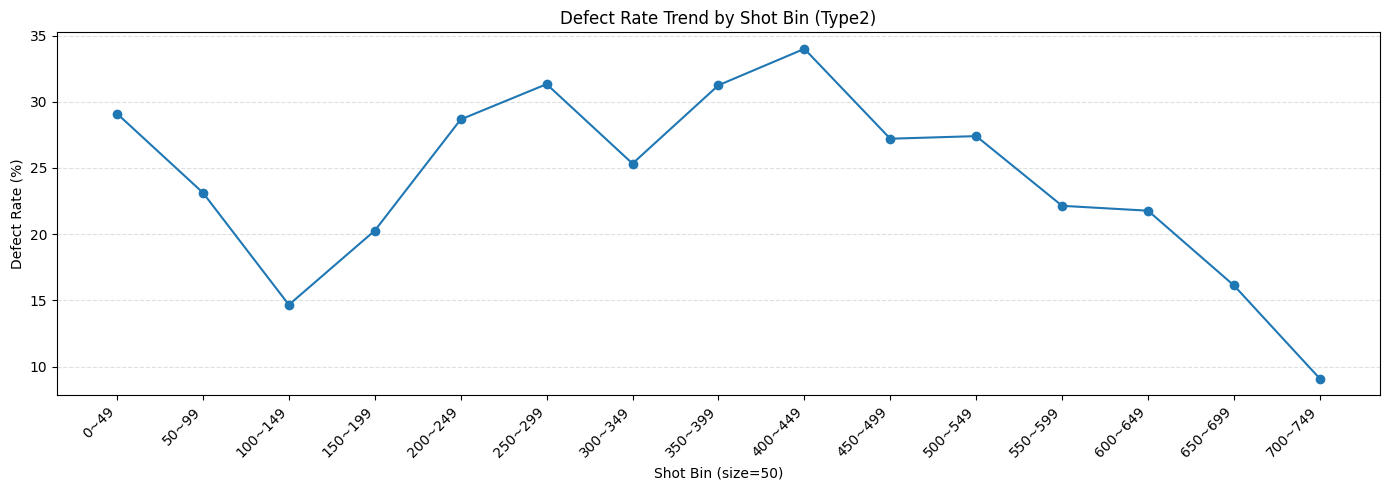

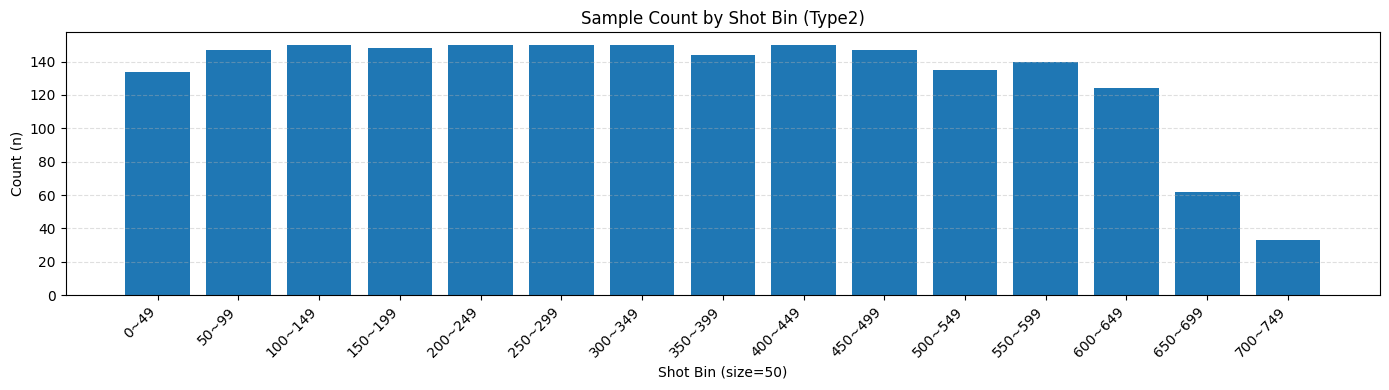

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1) Load
# =========================
path = "../../data/df_final_Type2.csv"
df = pd.read_csv(path)

# 컬럼명 공백 제거(혹시 모를 경우 대비)
df.columns = df.columns.str.strip()

# shot / Defect_Status 존재 확인
assert 'Shot' in df.columns, "❌ 'Shot' 컬럼이 없습니다."
assert 'Defect_Status' in df.columns, "❌ 'Defect_Status' 컬럼이 없습니다."

# shot 정렬 (shot이 시간 순서에 가장 가깝다고 가정)
df = df.sort_values('Shot').reset_index(drop=True)

# =========================
# 2) Shot 50개씩 구간 bin 만들기
#    (예: 0~49, 50~99, ...)
# =========================
BIN_SIZE = 50

# Shot이 0부터 시작한다는 가정이 불확실하면 min부터 시작하도록
shot_min = int(df['Shot'].min())
shot_max = int(df['Shot'].max())

# bin 경계 생성: [shot_min, shot_min+50, ... , shot_max+1]
bins = np.arange(shot_min, shot_max + BIN_SIZE + 1, BIN_SIZE)

# 구간 라벨(보기 좋게)
labels = [f"{b}~{b+BIN_SIZE-1}" for b in bins[:-1]]

df['Shot_Bin'] = pd.cut(df['Shot'], bins=bins, labels=labels, right=False, include_lowest=True)

# =========================
# 3) 구간별 불량률 계산
# =========================
trend = (
    df.groupby('Shot_Bin', observed=True)
      .agg(
          n=('Defect_Status', 'size'),
          defect_rate=('Defect_Status', 'mean'),
          defect_cnt=('Defect_Status', 'sum')
      )
      .reset_index()
)

trend['defect_rate_pct'] = trend['defect_rate'] * 100

# =========================
# 4) 트렌드 확인용 출력
# =========================
print("✅ Shot 구간(50개 단위)별 불량률 요약")
display(trend)

# =========================
# 5) Plot (불량률 트렌드)
# =========================
plt.figure(figsize=(14, 5))
plt.plot(trend['Shot_Bin'].astype(str), trend['defect_rate_pct'], marker='o')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Defect Rate (%)')
plt.xlabel(f'Shot Bin (size={BIN_SIZE})')
plt.title('Defect Rate Trend by Shot Bin (Type2)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# =========================
# 6) (선택) 구간별 표본 수(n)도 같이 보기
# =========================
plt.figure(figsize=(14, 4))
plt.bar(trend['Shot_Bin'].astype(str), trend['n'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count (n)')
plt.xlabel(f'Shot Bin (size={BIN_SIZE})')
plt.title('Sample Count by Shot Bin (Type2)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# XGBoost 튜닝
xgb_params = {
    'n_estimators':     [200, 400, 600],
    'max_depth':        [4, 6, 8],
    'learning_rate':    [0.03, 0.05, 0.1, 0.2],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.1, 0.3],
}
xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(scale_pos_weight=pos_weight, random_state=SEED,
                      eval_metric='logloss', verbosity=0),
    xgb_params, n_iter=40,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='recall', n_jobs=-1, random_state=SEED, verbose=1
)
xgb_search.fit(X_train_xgb, y_train)
best_xgb = xgb_search.best_estimator_

print(f"\n✅ XGBoost 최적 파라미터 (CV Recall: {xgb_search.best_score_:.4f})")
for k, v in xgb_search.best_params_.items():
    print(f"   {k}: {v}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits

✅ XGBoost 최적 파라미터 (CV Recall: 0.6332)
   subsample: 0.7
   n_estimators: 200
   min_child_weight: 1
   max_depth: 4
   learning_rate: 0.03
   gamma: 0.3
   colsample_bytree: 1.0
